# Cryptography - Comparison of Eavesdroppers in BB84 Protocol

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100_000
ATTACK_PROB = 0.5
ENTANGLE_DISTURB = 0.1
CHANNEL_NOISE = 0.05


In [8]:
def sift(alice_bits, bob_bits, alice_bases, bob_bases):
    mask = alice_bases == bob_bases
    return alice_bits[mask], bob_bits[mask], mask

def compute_metrics(alice_key, bob_key, eve_key):
    qber = np.mean(alice_key != bob_key)
    eve_info = np.mean(alice_key == eve_key)
    return len(alice_key), qber, eve_info

def apply_noise(bits, noise_prob):
    flips = np.random.rand(len(bits)) < noise_prob
    noisy = bits.copy()
    noisy[flips] ^= 1
    return noisy

def generate_bb84():
    alice_bits = np.random.randint(0, 2, N)
    alice_bases = np.random.randint(0, 2, N)
    bob_bases = np.random.randint(0, 2, N)
    return alice_bits, alice_bases, bob_bases


## Baseline

In [9]:
def baseline(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    bob_bits = np.where(
        alice_bases == bob_bases,
        alice_bits,
        np.random.randint(0, 2, N)
    )

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, _ = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    eve_key = np.random.randint(0, 2, len(alice_key))
    return compute_metrics(alice_key, bob_key, eve_key)


## Intercept-Resend

In [10]:
def intercept_resend(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    eve_bases = np.random.randint(0, 2, N)
    eve_bits = np.where(
        eve_bases == alice_bases,
        alice_bits,
        np.random.randint(0, 2, N)
    )

    bob_bits = np.where(
        bob_bases == eve_bases,
        eve_bits,
        np.random.randint(0, 2, N)
    )

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, mask = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    eve_key = eve_bits[mask]
    return compute_metrics(alice_key, bob_key, eve_key)


## Random-Basis Partial Measurement Attack

In [11]:
def random_basis_attack(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    eve_bases = np.random.randint(0, 2, N)
    eve_bits = alice_bits.copy()

    attack_mask = np.random.rand(N) < ATTACK_PROB
    disturbed = attack_mask & (eve_bases != alice_bases)
    eve_bits[disturbed] = np.random.randint(0, 2, np.sum(disturbed))

    bob_bits = np.where(
        bob_bases == eve_bases,
        eve_bits,
        np.random.randint(0, 2, N)
    )

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, mask = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    eve_key = eve_bits[mask]
    return compute_metrics(alice_key, bob_key, eve_key)


## Entanglement-based probe attack

In [12]:
def entanglement_probe(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    eve_bits = alice_bits.copy()
    disturb = np.random.rand(N) < ENTANGLE_DISTURB
    eve_bits[disturb] = np.random.randint(0, 2, np.sum(disturb))

    bob_bits = np.where(
        alice_bases == bob_bases,
        eve_bits,
        np.random.randint(0, 2, N)
    )

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, mask = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    eve_key = eve_bits[mask]
    return compute_metrics(alice_key, bob_key, eve_key)


## Photon Number Splitting Attack

In [38]:
MU = 0.5          # mean photon number (weak coherent pulse)
def pns_attack(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    # Photon number per pulse (Poisson distribution)
    photon_numbers = np.random.poisson(MU, N)

    eve_bits = np.full(N, -1)   # -1 = Eve has no info
    bob_bits = np.zeros(N, dtype=int)

    for i in range(N):
        if photon_numbers[i] == 0:
            # No photon reaches Bob
            bob_bits[i] = np.random.randint(0, 2)

        elif photon_numbers[i] == 1:
            # Single-photon pulse: Eve cannot attack safely
            if alice_bases[i] == bob_bases[i]:
                bob_bits[i] = alice_bits[i]
            else:
                bob_bits[i] = np.random.randint(0, 2)

        else:
            # Multi-photon pulse: Eve performs PNS
            eve_bits[i] = alice_bits[i]  # Eve stores photon
            if alice_bases[i] == bob_bases[i]:
                bob_bits[i] = alice_bits[i]
            else:
                bob_bits[i] = np.random.randint(0, 2)

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, mask = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    # Eve only knows bits from multi-photon pulses
    eve_key = eve_bits[mask]
    valid = eve_key != -1

    eve_info = np.mean(alice_key[valid] == eve_key[valid]) if np.any(valid) else 0.0
    qber = np.mean(alice_key != bob_key)

    return len(alice_key), qber, eve_info


## Run Simulations

In [39]:
methods = {
    "Baseline": baseline,
    "Intercept–Resend": intercept_resend,
    "Random-Basis": random_basis_attack,
    "Entanglement Probe": entanglement_probe,
    "PNS Attack": pns_attack}

results_ideal = {}
results_noisy = {}

for name, func in methods.items():
    results_ideal[name] = func(noise=False)
    results_noisy[name] = func(noise=True)


In [40]:
def print_results(title, results):
    print(f"\n===== {title} =====")
    for method, (key_len, qber, eve_info) in results.items():
        print(f"\n{method}")
        print(f"  Sifted Key Length      : {key_len}")
        print(f"  QBER                   : {qber:.6f}")
        print(f"  Eve Correct Bit Fraction: {eve_info:.6f}")

print_results("IDEAL CHANNEL RESULTS", results_ideal)
print_results("NOISY CHANNEL RESULTS", results_noisy)



===== IDEAL CHANNEL RESULTS =====

Baseline
  Sifted Key Length      : 50195
  QBER                   : 0.000000
  Eve Correct Bit Fraction: 0.498795

Intercept–Resend
  Sifted Key Length      : 50015
  QBER                   : 0.251045
  Eve Correct Bit Fraction: 0.748475

Random-Basis
  Sifted Key Length      : 49836
  QBER                   : 0.247753
  Eve Correct Bit Fraction: 0.751124

Entanglement Probe
  Sifted Key Length      : 50287
  QBER                   : 0.149263
  Eve Correct Bit Fraction: 0.850737

PNS Attack
  Sifted Key Length      : 49772
  QBER                   : 0.298521
  Eve Correct Bit Fraction: 1.000000

===== NOISY CHANNEL RESULTS =====

Baseline
  Sifted Key Length      : 50009
  QBER                   : 0.051231
  Eve Correct Bit Fraction: 0.503669

Intercept–Resend
  Sifted Key Length      : 50301
  QBER                   : 0.271844
  Eve Correct Bit Fraction: 0.752172

Random-Basis
  Sifted Key Length      : 50140
  QBER                   : 0.275768
  E

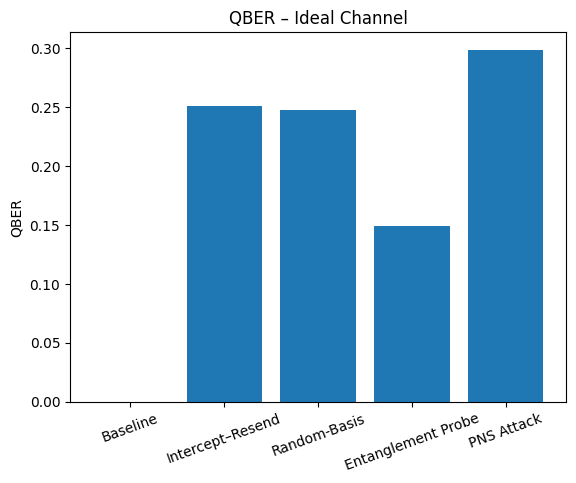

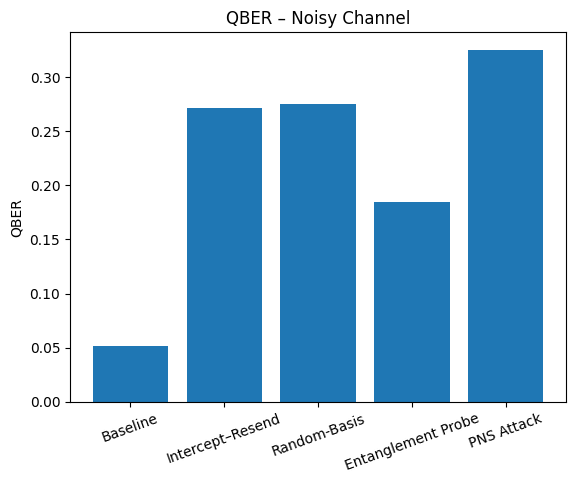

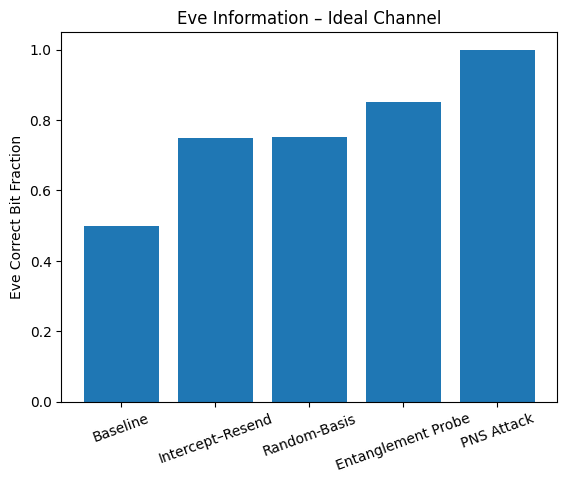

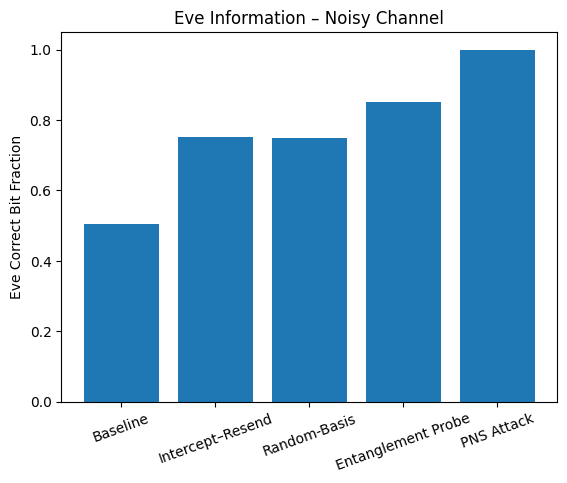

In [41]:
labels = list(methods.keys())

qber_ideal = [results_ideal[m][1] for m in labels]
qber_noisy = [results_noisy[m][1] for m in labels]

eve_ideal = [results_ideal[m][2] for m in labels]
eve_noisy = [results_noisy[m][2] for m in labels]

# QBER plots
plt.figure()
plt.bar(labels, qber_ideal)
plt.ylabel("QBER")
plt.title("QBER – Ideal Channel")
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(labels, qber_noisy)
plt.ylabel("QBER")
plt.title("QBER – Noisy Channel")
plt.xticks(rotation=20)
plt.show()

# Eve information plots
plt.figure()
plt.bar(labels, eve_ideal)
plt.ylabel("Eve Correct Bit Fraction")
plt.title("Eve Information – Ideal Channel")
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(labels, eve_noisy)
plt.ylabel("Eve Correct Bit Fraction")
plt.title("Eve Information – Noisy Channel")
plt.xticks(rotation=20)
plt.show()


## Multi-Run

In [42]:
def run_multiple(method_func, runs=20, noise=False):
    key_lengths = []
    qbers = []
    eve_infos = []

    for _ in range(runs):
        key_len, qber, eve_info = method_func(noise=noise)
        key_lengths.append(key_len)
        qbers.append(qber)
        eve_infos.append(eve_info)

    return {
        "key_len_mean": np.mean(key_lengths),
        "key_len_std": np.std(key_lengths),
        "qber_mean": np.mean(qbers),
        "qber_std": np.std(qbers),
        "eve_mean": np.mean(eve_infos),
        "eve_std": np.std(eve_infos)
    }


In [43]:
RUNS = 30

avg_results_ideal = {}
avg_results_noisy = {}

for name, func in methods.items():
    avg_results_ideal[name] = run_multiple(func, runs=RUNS, noise=False)
    avg_results_noisy[name] = run_multiple(func, runs=RUNS, noise=True)


In [44]:
def print_avg_results(title, results):
    print(f"\n===== {title} =====")
    for method, r in results.items():
        print(f"\n{method}")
        print(f"  Key Length     : {r['key_len_mean']:.1f} ± {r['key_len_std']:.1f}")
        print(f"  QBER           : {r['qber_mean']:.5f} ± {r['qber_std']:.5f}")
        print(f"  Eve Info       : {r['eve_mean']:.5f} ± {r['eve_std']:.5f}")

print_avg_results("IDEAL CHANNEL (Averaged)", avg_results_ideal)
print_avg_results("NOISY CHANNEL (Averaged)", avg_results_noisy)



===== IDEAL CHANNEL (Averaged) =====

Baseline
  Key Length     : 49961.4 ± 141.5
  QBER           : 0.00000 ± 0.00000
  Eve Info       : 0.50023 ± 0.00273

Intercept–Resend
  Key Length     : 49982.0 ± 166.1
  QBER           : 0.25010 ± 0.00212
  Eve Info       : 0.74991 ± 0.00185

Random-Basis
  Key Length     : 50001.6 ± 160.8
  QBER           : 0.25015 ± 0.00226
  Eve Info       : 0.74998 ± 0.00213

Entanglement Probe
  Key Length     : 49969.0 ± 156.1
  QBER           : 0.14950 ± 0.00192
  Eve Info       : 0.85050 ± 0.00192

PNS Attack
  Key Length     : 50035.8 ± 138.5
  QBER           : 0.30307 ± 0.00211
  Eve Info       : 1.00000 ± 0.00000

===== NOISY CHANNEL (Averaged) =====

Baseline
  Key Length     : 49971.8 ± 140.4
  QBER           : 0.04959 ± 0.00105
  Eve Info       : 0.49985 ± 0.00274

Intercept–Resend
  Key Length     : 49975.8 ± 193.1
  QBER           : 0.27546 ± 0.00220
  Eve Info       : 0.74995 ± 0.00210

Random-Basis
  Key Length     : 50004.1 ± 162.5
  QBER    

## Parameter Sweep of Attack Probability

In [19]:
def parameter_sweep_random_basis(
    attack_probs,
    runs=20,
    noise=False
):
    qber_means = []
    qber_stds = []
    eve_means = []
    eve_stds = []

    global ATTACK_PROB

    for p in attack_probs:
        ATTACK_PROB = p

        qbers = []
        eves = []

        for _ in range(runs):
            _, qber, eve_info = random_basis_attack(noise=noise)
            qbers.append(qber)
            eves.append(eve_info)

        qber_means.append(np.mean(qbers))
        qber_stds.append(np.std(qbers))
        eve_means.append(np.mean(eves))
        eve_stds.append(np.std(eves))

    return (
        np.array(qber_means),
        np.array(qber_stds),
        np.array(eve_means),
        np.array(eve_stds)
    )


In [20]:
attack_probs = np.linspace(0, 1, 11)
RUNS = 30

# Ideal channel
qber_mean_i, qber_std_i, eve_mean_i, eve_std_i = \
    parameter_sweep_random_basis(
        attack_probs,
        runs=RUNS,
        noise=False
    )

# Noisy channel
qber_mean_n, qber_std_n, eve_mean_n, eve_std_n = \
    parameter_sweep_random_basis(
        attack_probs,
        runs=RUNS,
        noise=True
    )


In [21]:
print("=== PARAMETER SWEEP: RANDOM-BASIS ATTACK ===")
print("AttackProb | QBER (Ideal) ± Std | QBER (Noisy) ± Std")

for i, p in enumerate(attack_probs):
    print(
        f"{p:.2f}      | "
        f"{qber_mean_i[i]:.5f} ± {qber_std_i[i]:.5f} | "
        f"{qber_mean_n[i]:.5f} ± {qber_std_n[i]:.5f}"
    )


=== PARAMETER SWEEP: RANDOM-BASIS ATTACK ===
AttackProb | QBER (Ideal) ± Std | QBER (Noisy) ± Std
0.00      | 0.25018 ± 0.00193 | 0.27498 ± 0.00166
0.10      | 0.25025 ± 0.00183 | 0.27469 ± 0.00229
0.20      | 0.24980 ± 0.00202 | 0.27474 ± 0.00191
0.30      | 0.24984 ± 0.00158 | 0.27531 ± 0.00179
0.40      | 0.24986 ± 0.00162 | 0.27456 ± 0.00147
0.50      | 0.24977 ± 0.00175 | 0.27474 ± 0.00172
0.60      | 0.25017 ± 0.00200 | 0.27449 ± 0.00172
0.70      | 0.24982 ± 0.00143 | 0.27475 ± 0.00218
0.80      | 0.24929 ± 0.00197 | 0.27501 ± 0.00207
0.90      | 0.24998 ± 0.00200 | 0.27522 ± 0.00191
1.00      | 0.24957 ± 0.00209 | 0.27538 ± 0.00237


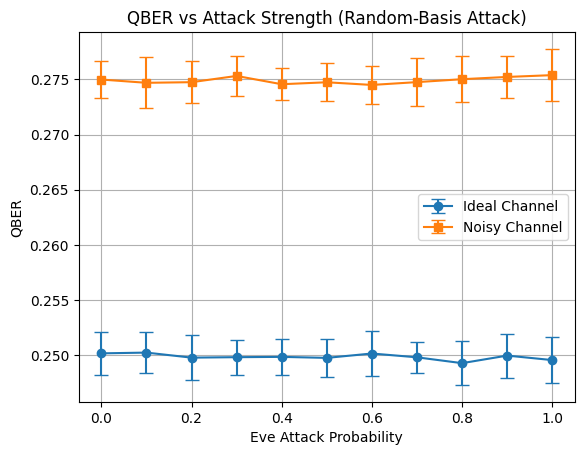

In [22]:
plt.figure()
plt.errorbar(
    attack_probs,
    qber_mean_i,
    yerr=qber_std_i,
    marker='o',
    capsize=5,
    label="Ideal Channel"
)

plt.errorbar(
    attack_probs,
    qber_mean_n,
    yerr=qber_std_n,
    marker='s',
    capsize=5,
    label="Noisy Channel"
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("QBER")
plt.title("QBER vs Attack Strength (Random-Basis Attack)")
plt.legend()
plt.grid(True)
plt.show()


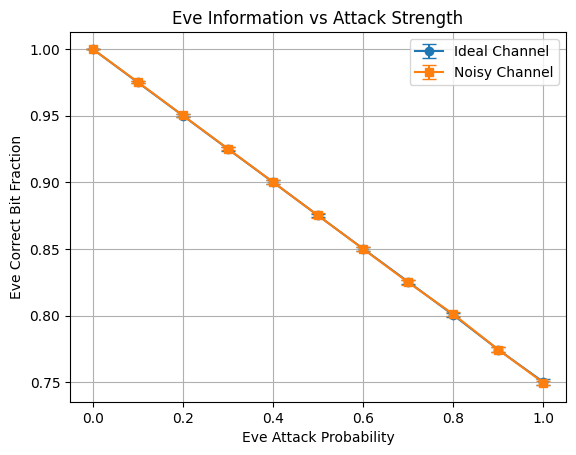

In [23]:
plt.figure()
plt.errorbar(
    attack_probs,
    eve_mean_i,
    yerr=eve_std_i,
    marker='o',
    capsize=5,
    label="Ideal Channel"
)

plt.errorbar(
    attack_probs,
    eve_mean_n,
    yerr=eve_std_n,
    marker='s',
    capsize=5,
    label="Noisy Channel"
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("Eve Correct Bit Fraction")
plt.title("Eve Information vs Attack Strength")
plt.legend()
plt.grid(True)
plt.show()


## Parameter Sweep for Entanglement Probability

In [24]:
def parameter_sweep_entanglement(
    disturb_values,
    runs=20,
    noise=False
):
    qber_means = []
    qber_stds = []
    eve_means = []
    eve_stds = []

    global ENTANGLE_DISTURB

    for d in disturb_values:
        ENTANGLE_DISTURB = d

        qbers = []
        eves = []

        for _ in range(runs):
            _, qber, eve_info = entanglement_probe(noise=noise)
            qbers.append(qber)
            eves.append(eve_info)

        qber_means.append(np.mean(qbers))
        qber_stds.append(np.std(qbers))
        eve_means.append(np.mean(eves))
        eve_stds.append(np.std(eves))

    return (
        np.array(qber_means),
        np.array(qber_stds),
        np.array(eve_means),
        np.array(eve_stds)
    )


In [25]:
disturb_vals = np.linspace(0, 0.3, 11)
RUNS = 30

# Ideal channel
qber_ei, qber_ei_std, eve_ei, eve_ei_std = \
    parameter_sweep_entanglement(
        disturb_vals,
        runs=RUNS,
        noise=False
    )

# Noisy channel
qber_en, qber_en_std, eve_en, eve_en_std = \
    parameter_sweep_entanglement(
        disturb_vals,
        runs=RUNS,
        noise=True
    )


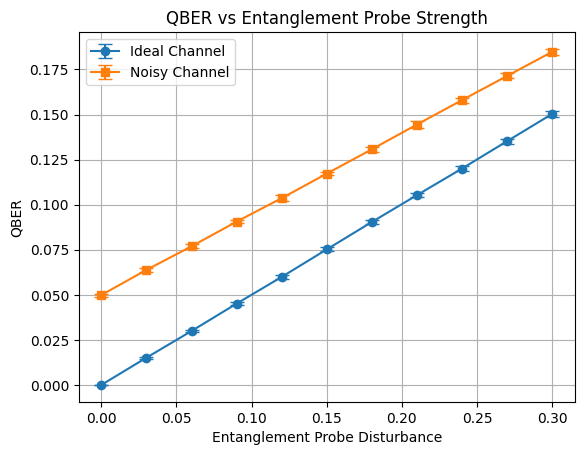

In [26]:
plt.figure()
plt.errorbar(
    disturb_vals,
    qber_ei,
    yerr=qber_ei_std,
    marker='o',
    capsize=5,
    label="Ideal Channel"
)

plt.errorbar(
    disturb_vals,
    qber_en,
    yerr=qber_en_std,
    marker='s',
    capsize=5,
    label="Noisy Channel"
)

plt.xlabel("Entanglement Probe Disturbance")
plt.ylabel("QBER")
plt.title("QBER vs Entanglement Probe Strength")
plt.legend()
plt.grid(True)
plt.show()


## Detectability Evaluation

In [45]:
QBER_THRESHOLD = 0.25

def detectability_test(method_func, runs=50, noise=False):
    detected = 0
    qbers = []

    for _ in range(runs):
        _, qber, _ = method_func(noise=noise)
        qbers.append(qber)
        if qber > QBER_THRESHOLD:
            detected += 1

    return {
        "mean_qber": np.mean(qbers),
        "std_qber": np.std(qbers),
        "detection_rate": detected / runs
    }


In [46]:
detect_ideal = {}
detect_noisy = {}

for name, func in methods.items():
    detect_ideal[name] = detectability_test(func, noise=False)
    detect_noisy[name] = detectability_test(func, noise=True)


In [47]:
def print_detectability(title, results):
    print(f"\n===== {title} =====")
    for method, r in results.items():
        print(f"\n{method}")
        print(f"  Mean QBER        : {r['mean_qber']:.5f} ± {r['std_qber']:.5f}")
        print(f"  Detection Rate  : {r['detection_rate']:.2f}")

print_detectability("DETECTABILITY — IDEAL CHANNEL", detect_ideal)
print_detectability("DETECTABILITY — NOISY CHANNEL", detect_noisy)



===== DETECTABILITY — IDEAL CHANNEL =====

Baseline
  Mean QBER        : 0.00000 ± 0.00000
  Detection Rate  : 0.00

Intercept–Resend
  Mean QBER        : 0.24974 ± 0.00194
  Detection Rate  : 0.44

Random-Basis
  Mean QBER        : 0.24987 ± 0.00178
  Detection Rate  : 0.42

Entanglement Probe
  Mean QBER        : 0.15008 ± 0.00150
  Detection Rate  : 0.00

PNS Attack
  Mean QBER        : 0.30322 ± 0.00189
  Detection Rate  : 1.00

===== DETECTABILITY — NOISY CHANNEL =====

Baseline
  Mean QBER        : 0.05000 ± 0.00102
  Detection Rate  : 0.00

Intercept–Resend
  Mean QBER        : 0.27500 ± 0.00195
  Detection Rate  : 1.00

Random-Basis
  Mean QBER        : 0.27496 ± 0.00177
  Detection Rate  : 1.00

Entanglement Probe
  Mean QBER        : 0.18470 ± 0.00154
  Detection Rate  : 0.00

PNS Attack
  Mean QBER        : 0.32255 ± 0.00202
  Detection Rate  : 1.00


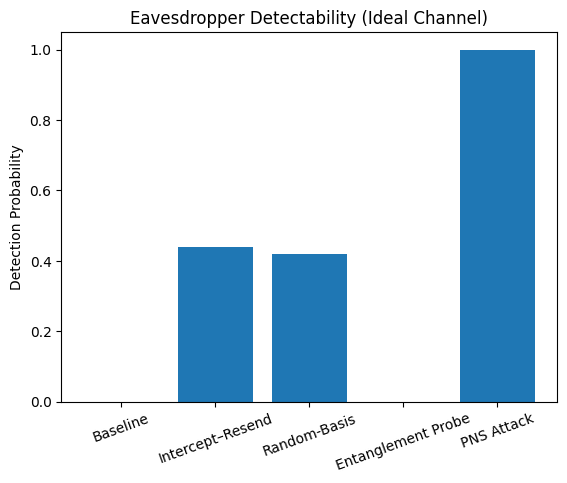

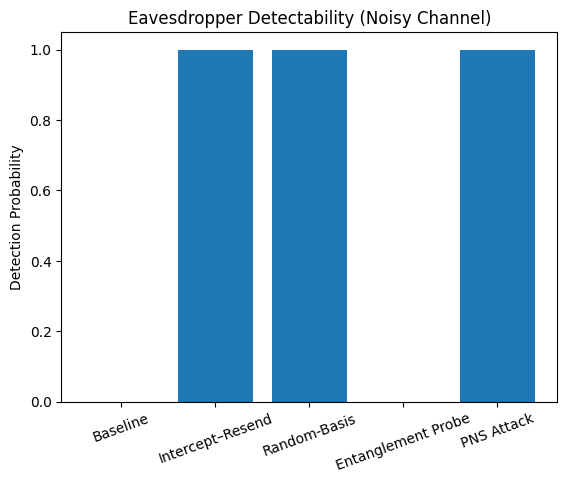

In [48]:
labels = list(methods.keys())

detect_rates_ideal = [detect_ideal[m]["detection_rate"] for m in labels]
detect_rates_noisy = [detect_noisy[m]["detection_rate"] for m in labels]

plt.figure()
plt.bar(labels, detect_rates_ideal)
plt.ylabel("Detection Probability")
plt.title("Eavesdropper Detectability (Ideal Channel)")
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(labels, detect_rates_noisy)
plt.ylabel("Detection Probability")
plt.title("Eavesdropper Detectability (Noisy Channel)")
plt.xticks(rotation=20)
plt.show()


## Photon Number Splitting Attack

In [35]:
MU = 0.5          # mean photon number (weak coherent pulse)
def pns_attack(noise=False):
    alice_bits, alice_bases, bob_bases = generate_bb84()

    # Photon number per pulse (Poisson distribution)
    photon_numbers = np.random.poisson(MU, N)

    eve_bits = np.full(N, -1)   # -1 = Eve has no info
    bob_bits = np.zeros(N, dtype=int)

    for i in range(N):
        if photon_numbers[i] == 0:
            # No photon reaches Bob
            bob_bits[i] = np.random.randint(0, 2)

        elif photon_numbers[i] == 1:
            # Single-photon pulse: Eve cannot attack safely
            if alice_bases[i] == bob_bases[i]:
                bob_bits[i] = alice_bits[i]
            else:
                bob_bits[i] = np.random.randint(0, 2)

        else:
            # Multi-photon pulse: Eve performs PNS
            eve_bits[i] = alice_bits[i]  # Eve stores photon
            if alice_bases[i] == bob_bases[i]:
                bob_bits[i] = alice_bits[i]
            else:
                bob_bits[i] = np.random.randint(0, 2)

    if noise:
        bob_bits = apply_noise(bob_bits, CHANNEL_NOISE)

    alice_key, bob_key, mask = sift(
        alice_bits, bob_bits, alice_bases, bob_bases
    )

    # Eve only knows bits from multi-photon pulses
    eve_key = eve_bits[mask]
    valid = eve_key != -1

    eve_info = np.mean(alice_key[valid] == eve_key[valid]) if np.any(valid) else 0.0
    qber = np.mean(alice_key != bob_key)

    return len(alice_key), qber, eve_info
methods["PNS Attack"] = pns_attack


In [36]:
def run_multiple(method_func, runs=20, noise=False):
    key_lengths = []
    qbers = []
    eve_infos = []

    for _ in range(runs):
        key_len, qber, eve_info = method_func(noise=noise)
        key_lengths.append(key_len)
        qbers.append(qber)
        eve_infos.append(eve_info)

    return {
        "key_len_mean": np.mean(key_lengths),
        "key_len_std": np.std(key_lengths),
        "qber_mean": np.mean(qbers),
        "qber_std": np.std(qbers),
        "eve_mean": np.mean(eve_infos),
        "eve_std": np.std(eve_infos)
    }
RUNS = 30

avg_results_ideal = {}
avg_results_noisy = {}

for name, func in methods.items():
    avg_results_ideal[name] = run_multiple(func, runs=RUNS, noise=False)
    avg_results_noisy[name] = run_multiple(func, runs=RUNS, noise=True)
def print_avg_results(title, results):
    print(f"\n===== {title} =====")
    for method, r in results.items():
        print(f"\n{method}")
        print(f"  Key Length     : {r['key_len_mean']:.1f} ± {r['key_len_std']:.1f}")
        print(f"  QBER           : {r['qber_mean']:.5f} ± {r['qber_std']:.5f}")
        print(f"  Eve Info       : {r['eve_mean']:.5f} ± {r['eve_std']:.5f}")

print_avg_results("IDEAL CHANNEL (Averaged)", avg_results_ideal)
print_avg_results("NOISY CHANNEL (Averaged)", avg_results_noisy)



===== IDEAL CHANNEL (Averaged) =====

Baseline
  Key Length     : 50004.6 ± 176.2
  QBER           : 0.00000 ± 0.00000
  Eve Info       : 0.49990 ± 0.00205

Intercept–Resend
  Key Length     : 50005.5 ± 128.6
  QBER           : 0.24969 ± 0.00241
  Eve Info       : 0.74987 ± 0.00211

Random-Basis
  Key Length     : 50016.4 ± 166.2
  QBER           : 0.25052 ± 0.00202
  Eve Info       : 0.74960 ± 0.00193

Entanglement Probe
  Key Length     : 50021.1 ± 162.5
  QBER           : 0.15007 ± 0.00146
  Eve Info       : 0.84993 ± 0.00146

PNS Attack
  Key Length     : 49968.1 ± 174.8
  QBER           : 0.30296 ± 0.00158
  Eve Info       : 1.00000 ± 0.00000

===== NOISY CHANNEL (Averaged) =====

Baseline
  Key Length     : 49982.2 ± 143.1
  QBER           : 0.04988 ± 0.00086
  Eve Info       : 0.49995 ± 0.00238

Intercept–Resend
  Key Length     : 50031.2 ± 156.1
  QBER           : 0.27504 ± 0.00203
  Eve Info       : 0.75016 ± 0.00210

Random-Basis
  Key Length     : 50011.6 ± 149.2
  QBER    